In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

a, b = 0, 100
n = 20



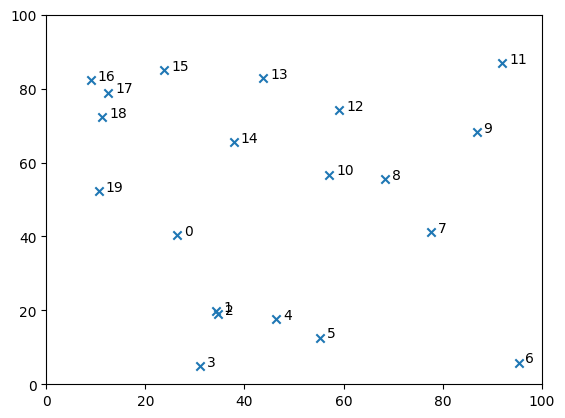

In [2]:
np.random.seed(761) # 19 failure
xy = np.random.uniform(a, b, (n, 2)).astype(np.float32)
com = np.mean(xy, axis=0)

thetas = []
for i in range(n):
    r = np.linalg.norm(com - xy[i]) 
    theta = np.arctan2(((xy[i, 1] - com[1]) / r), ((xy[i, 0] - com[0]) / r))
    thetas.append(theta)

thetas = np.array(thetas)
sorted_idx = np.argsort(thetas)
thetas = thetas[sorted_idx]
xy = xy[sorted_idx]


fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(xy[:, 0], xy[:, 1], marker='x')
for i in range(n):
    x, y = xy[i]
    ax.annotate('%s' %i, xy=(x, y), xytext=(5,0), textcoords='offset points')

plt.xlim(a, b)
plt.ylim(a, b)

plt.show()

In [3]:
def get_extreme_indices(xy, verbose=False) -> list:
    
    n = xy.shape[0]
    extreme_idcs = []

    for i in range(n):
        x, y = xy[i, 0], xy[i, 1]
        xy_ = xy[[*range(i), *range(i+1, len(xy))]]

        if (not any(x < xy_[:, 0])) or (not any(x > xy_[:, 0])):
            if verbose:
                print(f"Extreme point: {i}: ({x}, {y}) in x axis")
            extreme_idcs.append(i)
        elif (not any(y < xy_[:, 1])) or (not any(y > xy_[:, 1])):
            if verbose:
                print(f"Extreme point: {i}: ({x}, {y}) in y axis")
            extreme_idcs.append(i)
        else:
            continue

    return np.array(extreme_idcs)


def is_vertex(i, xy, extreme_indices, verbose=False):
    if i in extreme_indices:
        return True, extreme_indices
    
    x, y = xy[i, 0], xy[i, 1]
    n = xy.shape[0]
    xy_ = xy[extreme_indices]
    xy_no_i = xy[[*range(i), *range(i+1, n)]]

    extreme_zwischen_idx = np.sum(extreme_indices < i)
    n_ = xy_.shape[0]
    # print(f"Nearest extremes to {i}: {extreme_indices[extreme_zwischen_idx%n_]} and {extreme_indices[extreme_zwischen_idx-1]}")
    
    m = (xy_[(extreme_zwischen_idx)%n_, 1] - xy_[extreme_zwischen_idx-1, 1]) / (xy_[(extreme_zwischen_idx)%n_, 0] - xy_[extreme_zwischen_idx-1, 0] )

    pos_slope_line_vals = xy_no_i[:, 1] - y - m * (xy_no_i[:, 0] - x)
    neg_slope_line_vals = xy_no_i[:, 1] - y + m * (xy_no_i[:, 0] - x)

    # np.sum((np.array([2, 6, 10, 14]) <7))

    if all(pos_slope_line_vals >= 0) or all(pos_slope_line_vals < 0):
        if verbose:
            print(f"Extreme point: {i}: ({x}, {y}) in positive neigbour slope line")
        extreme_indices = np.append(extreme_indices, [i])
        return True, extreme_indices
    elif all(neg_slope_line_vals >= 0) or all(neg_slope_line_vals < 0):
        if verbose:
            print(f"Extreme point: {i}: ({x}, {y}) in negative neigbour slope line")
        extreme_indices = np.append(extreme_indices, [i])
        return True , extreme_indices
    else:
        if verbose:
            print(f"Non-Extreme point: {i}: ({x}, {y})")
            # print(f"Positive slope line values: {pos_slope_line_vals}")
            # print(f"Negative slope line values: {neg_slope_line_vals}")
            print(f"Nearest extremes to {i}: {extreme_indices[extreme_zwischen_idx%n_]} and {extreme_indices[extreme_zwischen_idx-1]}")
        return False, extreme_indices

In [4]:
def convex_hull(xy):
    extreme_indices = get_extreme_indices(xy)
    for i in range(n):
        x, y = xy[i]
        _, extreme_indices = is_vertex(i, xy, extreme_indices)
        extreme_indices = np.sort(extreme_indices)

    vertices = []
    # extreme_indices = get_extreme_indices(xy)
    for i in range(n):
        x, y = xy[i]
        vertex_found, extreme_indices = is_vertex(i, xy, extreme_indices)
        extreme_indices = np.sort(extreme_indices)

        if vertex_found:
            vertices.append([x, y])


    return np.array(vertices)

In [5]:

vertices = convex_hull(xy)


In [6]:
xy.shape, vertices.shape

((20, 2), (6, 2))

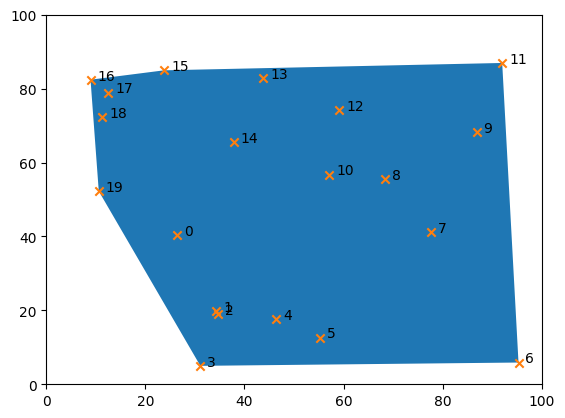

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.fill(vertices[:, 0], vertices[:, 1])
ax.scatter(xy[:, 0], xy[:, 1], marker='x')
for i in range(n):
    x, y = xy[i]
    ax.annotate('%s' %i, xy=(x, y), xytext=(5,0), textcoords='offset points')

plt.xlim(a, b)
plt.ylim(a, b)

plt.show()

In [8]:
def sort_points(xy):
    com = np.mean(xy, axis=0)
    thetas = []
    for i in range(n):
        r = np.linalg.norm(com - xy[i]) 
        theta = np.arctan2(((xy[i, 1] - com[1]) / r), ((xy[i, 0] - com[0]) / r))
        thetas.append(theta)

    thetas = np.array(thetas)
    sorted_idx = np.argsort(thetas)
    thetas = thetas[sorted_idx]
    xy = xy[sorted_idx]

    return xy

def convex_hull(xy, verbose=False, return_extreme_indices=False):
    xy = sort_points(xy)
    extreme_indices = get_extreme_indices(xy, verbose=verbose)
    for i in range(n):
        x, y = xy[i]
        _, extreme_indices = is_vertex(i, xy, extreme_indices, verbose=verbose)
        extreme_indices = np.sort(extreme_indices)


    vertices = []
    # extreme_indices = get_extreme_indices(xy)
    prev_len_extreme_indices = np.nan
    next_len_extreme_indices = len(extreme_indices)
    count = 0
    MAX_ITER = 10
    
    while True:

        for i in range(n):
            x, y = xy[i]
            vertex_found, extreme_indices = is_vertex(i, xy, extreme_indices, verbose=verbose)
            extreme_indices = np.sort(extreme_indices)

            if vertex_found:
                vertices.append([x, y])

        prev_len_extreme_indices = next_len_extreme_indices
        next_len_extreme_indices = len(extreme_indices)

        count += 1
        if (prev_len_extreme_indices == next_len_extreme_indices) or (count > MAX_ITER):
            break
        


    if return_extreme_indices:
        return np.array(vertices), extreme_indices
    else:
        return np.array(vertices)

In [9]:
def opencv_hull(points):
    """Get convex hull using OpenCV."""
    points32 = np.asarray(points, dtype=np.float32)

    hull_indices = cv2.convexHull(
        points32,
        returnPoints=False
    )

    return points32[hull_indices[:, 0]]


In [10]:
opencv_hull(xy)

array([[31.102743 ,  4.9862533],
       [95.24416  ,  5.8842664],
       [91.95254  , 86.935    ],
       [23.790594 , 84.94329  ],
       [ 8.957923 , 82.407814 ],
       [10.621381 , 52.244385 ]], dtype=float32)

In [11]:
convex_hull(xy, verbose=False, return_extreme_indices=True)

(array([[31.102743 ,  4.9862533],
        [95.24416  ,  5.8842664],
        [91.95254  , 86.935    ],
        [23.790594 , 84.94329  ],
        [ 8.957923 , 82.407814 ],
        [10.621381 , 52.244385 ]], dtype=float32),
 array([ 3,  6, 11, 15, 16, 19]))

In [12]:
def normalize_hull(points, decimals=3):
    """Convert hull points into a set so ordering doesn't matter."""
    points = np.asarray(points, dtype=np.float64)
    return {tuple(np.round(point, decimals)) for point in points}

def test_case(points, name="test", verbose=False):
    """Compare your implementation against OpenCV."""

    # Your implementation
    my_hull, extreme_indices = convex_hull(points, return_extreme_indices=True)

    # OpenCV reference
    cv_hull = opencv_hull(points)
    

    my_set = normalize_hull(my_hull)
    cv_set = normalize_hull(cv_hull)

    passed = my_set == cv_set
    if not passed:
        with open("run.log", "a") as f:
            f.write(f"\n{name}\n")
            f.write("-" * 50 + "\n")
            f.write(f"Input points : {len(points)}\n")
            f.write(f"Your hull    : {len(my_set)} vertices\n")
            f.write(f"OpenCV hull  : {len(cv_set)} vertices\n")
            f.write(f"Vertices       : {[[float(x), float(y)] for x, y in my_set]}\n")
            f.write(f"Vertices OpenCV: {[[float(x), float(y)] for x, y in cv_set]}\n ")
            f.write(f"Vertex indices: {extreme_indices}\n")

    if verbose:
        print(f"\n{name}")
        print("-" * 50)
        print(f"Input points : {len(points)}")
        print(f"Your hull    : {len(my_set)} vertices")
        print(f"OpenCV hull  : {len(cv_set)} vertices")
        print(f"Result       : {'PASS' if passed else 'FAIL'}")

    if (not passed) and verbose:
        print("\nPoints found by OpenCV but not by your algorithm:")
        print(cv_set - my_set)

        print("\nPoints found by your algorithm but not OpenCV:")
        print(my_set - cv_set)

    return passed

In [13]:
# run tests


n_random_seeds = 10000
n_passed = 0
for seed in tqdm(range(n_random_seeds), desc="Running tests"):
    np.random.seed(seed)
    points = np.random.uniform(a, b, (n, 2))
    if test_case(points, name=f"Random seed {seed}", verbose=False):
        n_passed += 1

    


print(f"\n\n{n_passed}/{n_random_seeds} tests passed.")


Running tests:   0%|          | 0/10000 [00:00<?, ?it/s]



9835/10000 tests passed.
